**IMPORTANDO BIBLIOTECAS**

In [ ]:
#Bibliotecas de manipualção e visualização de dados
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_decision_regions
import seaborn as sns

#Dataset
from sklearn.datasets import load_iris

#Classes do modelo de aprendizado
from sklearn.neighbors import KNeighborsClassifier

#Funções de avaliação dos modelos
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Carregando o dataset
iris = load_iris()

# Transformando em DataFrame
dataset = pd.DataFrame(iris.data, columns=iris.feature_names)

# Adicionando a coluna da espécie
dataset['species'] = iris.target

**ANÁLISE DO CONJUNTO DE DADOS**

In [ ]:
print("Quantas classes existem nesse dataset?\n%d" %(len(dataset["species"].unique())))
print("\nQuantas instâncias existem no dataset?\n%d" %(len(dataset)))
print("\nQuantas features existem no dataset?\n%d" %(dataset.shape[1]))
print("\nQue features são essas?\n%s" %(str([k for k in dataset.keys()])))
print("\nQual o numero de instâncias por classe?")
print(dataset["species"].value_counts())

Quantas classes existem nesse dataset?
3

Quantas instâncias existem no dataset?
150

Quantas features existem no dataset?
5

Que features são essas?
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)', 'species']

Qual o numero de instâncias por classe?
species
0    50
1    50
2    50
Name: count, dtype: int64


In [ ]:
dataset

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


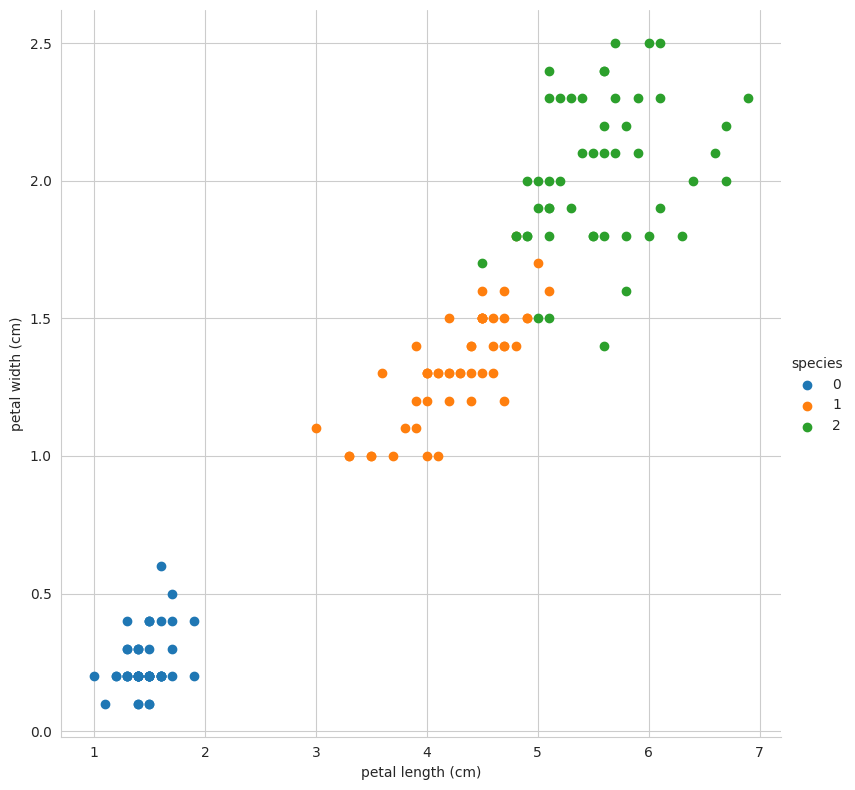

In [ ]:
# Distribuição das classes pelas features SepalLengthCm e SepalWidthCm
sns.set_style("whitegrid")
sns.FacetGrid(dataset, hue ="species",
              height = 8).map(plt.scatter,
                              'petal length (cm)',
                              'petal width (cm)').add_legend()

In [ ]:
# Mapeando os valores da classe para inteiro (para fins de visualização da região de decisão)
dataset['species'] = pd.factorize(dataset['species'])[0]
dataset

# Setosa - 0
# Versicolor - 1
# Virginica - 2

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


**SEPARANDO O CONJUNTO DE DADOS**

In [ ]:
#Vamos usar somente duas features SepalLengthCm e SepalWidthCm
X = dataset.iloc[:,[0,1]]
y = dataset.iloc[:,[4]]

#Separando o conjunto de dados em treinamento e teste
X_train, X_test, y_train, y_test = train_test_split(X, y)

In [ ]:
y_test

,species
125,2
110,2
82,1
145,2
124,2
103,2
40,0
33,0
126,2
149,2


**TREINAMENTO DO MODELO**

In [ ]:
model = KNeighborsClassifier()
#treinando o modelo
model.fit(X_train, y_train)

#predição
y_pred = model.predict(X_test)


#Resultados do classificador
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.92      0.96        12
           2       0.94      1.00      0.97        16

    accuracy                           0.97        38
   macro avg       0.98      0.97      0.98        38
weighted avg       0.98      0.97      0.97        38



**Métricas**

*   **Precision** - $\frac{tp}{(tp + fp)}$
*   **Recall** - $\frac{tp}{(tp + fn)}$
*   **F1-score** - $2 * \frac{(precision * recall)}{(precision + recall)}$
*   **Accuracy** - $\frac{C}{T}$
*   **Macro avg** - Calcule as métricas para cada rótulo e encontre sua média não ponderada.
*   **Weighted avg** - Calcule as métricas para cada rótulo e encontre sua média ponderada pelo suporte (o número de instâncias verdadeiras para cada rótulo).

**tp** - verdadeiros positivos

**fp** - falsos positivos

**fn** - falsos negativos

**C** - Número de predições corretas

**T** - Número total de predições

**REGIÃO DE DECISÃO**

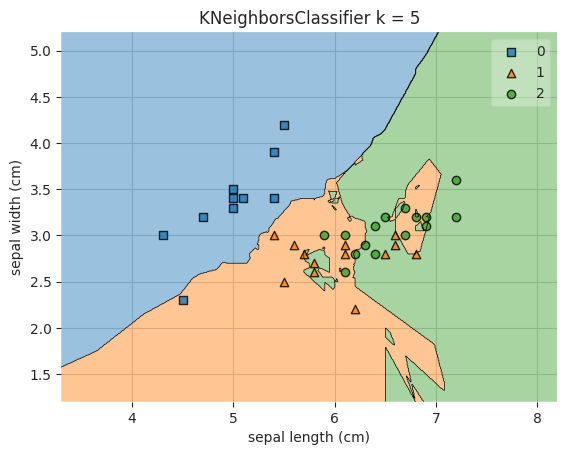

In [ ]:
plot_decision_regions(np.array([X_test["sepal length (cm)"].values, X_test["sepal width (cm)"].values]).T, y_test.values.reshape(-1,1).T[0], model)
plt.xlabel("sepal length (cm)")
plt.ylabel("sepal width (cm)")

plt.title(model.__class__.__name__ + " k = " + str(model.n_neighbors))
plt.show()

**VARIANDO O TAMANHO DA VIZINHANÇA**

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       0.58      0.64      0.61        11
           2       0.69      0.64      0.67        14

    accuracy                           0.76        38
   macro avg       0.76      0.76      0.76        38
weighted avg       0.77      0.76      0.76        38



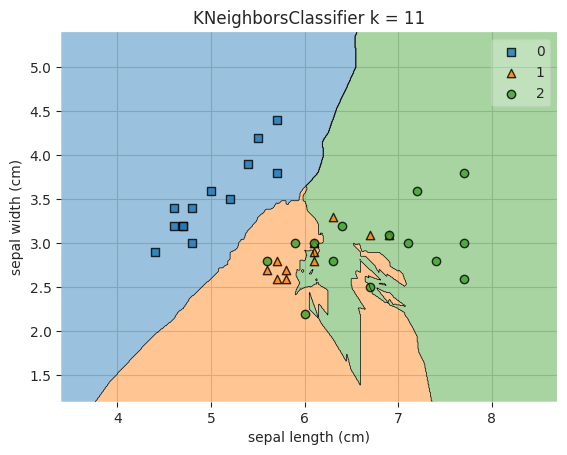

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       0.55      0.55      0.55        11
           2       0.64      0.64      0.64        14

    accuracy                           0.74        38
   macro avg       0.73      0.73      0.73        38
weighted avg       0.74      0.74      0.74        38



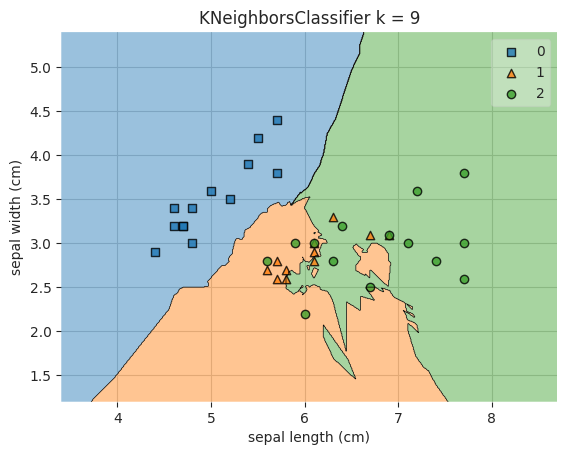

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       0.58      0.64      0.61        11
           2       0.69      0.64      0.67        14

    accuracy                           0.76        38
   macro avg       0.76      0.76      0.76        38
weighted avg       0.77      0.76      0.76        38



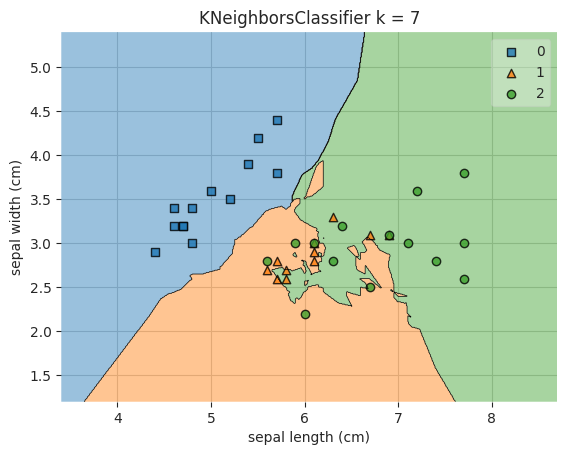

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       0.50      0.45      0.48        11
           2       0.60      0.64      0.62        14

    accuracy                           0.71        38
   macro avg       0.70      0.70      0.70        38
weighted avg       0.71      0.71      0.71        38



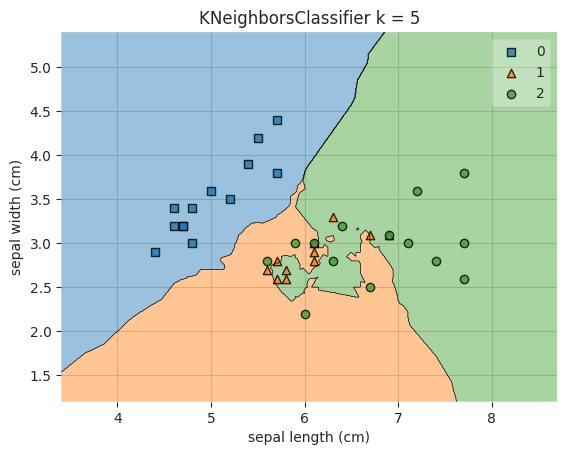

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       0.55      0.55      0.55        11
           2       0.64      0.64      0.64        14

    accuracy                           0.74        38
   macro avg       0.73      0.73      0.73        38
weighted avg       0.74      0.74      0.74        38



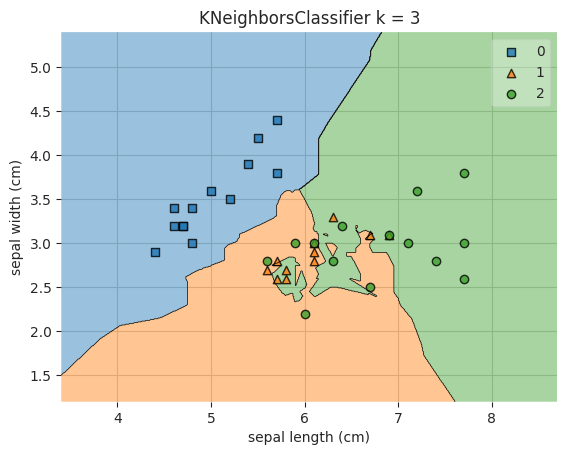

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       0.50      0.45      0.48        11
           2       0.60      0.64      0.62        14

    accuracy                           0.71        38
   macro avg       0.70      0.70      0.70        38
weighted avg       0.71      0.71      0.71        38



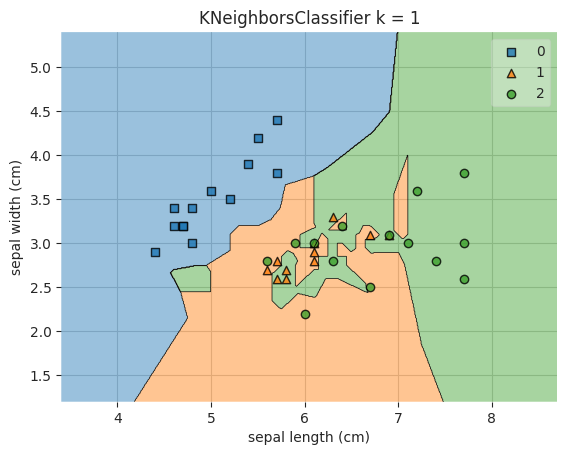

In [ ]:
for k in [11, 9, 7, 5, 3, 1]:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(classification_report(y_test, y_pred))

    plot_decision_regions(np.array([X_test["sepal length (cm)"].values, X_test["sepal width (cm)"].values]).T, y_test.values.reshape(-1,1).T[0], model)
    plt.xlabel("sepal length (cm)")
    plt.ylabel("sepal width (cm)")

    plt.title(model.__class__.__name__ + " k = " + str(model.n_neighbors))
    plt.show()

**MEDIDA DE DISTÂNCIA**

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       0.50      0.45      0.48        11
           2       0.60      0.64      0.62        14

    accuracy                           0.71        38
   macro avg       0.70      0.70      0.70        38
weighted avg       0.71      0.71      0.71        38



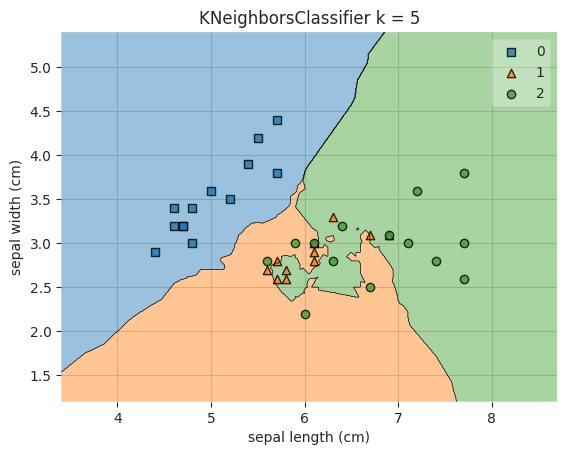

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       0.50      0.45      0.48        11
           2       0.60      0.64      0.62        14

    accuracy                           0.71        38
   macro avg       0.70      0.70      0.70        38
weighted avg       0.71      0.71      0.71        38



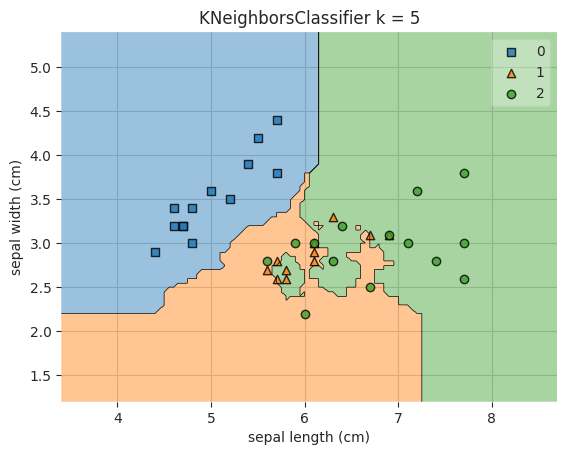

In [ ]:
for m in ["euclidean", "manhattan"]:
    model = KNeighborsClassifier(metric=m)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(classification_report(y_test, y_pred))

    plot_decision_regions(np.array([X_test["sepal length (cm)"].values, X_test["sepal width (cm)"].values]).T, y_test.values.reshape(-1,1).T[0], model)
    plt.xlabel("sepal length (cm)")
    plt.ylabel("sepal width (cm)")

    plt.title(model.__class__.__name__ + " k = " + str(model.n_neighbors))
    plt.show()